# Heart Disease Risk Prediction — Full Analysis

**Dataset:** Cleveland Heart Disease dataset (297 patients, 13 clinical features + target)

**Goal:** Explore the data, engineer features, train and tune several classification
models, compare them with proper cross-validation, interpret the best model, and
export it for deployment in a Streamlit app.

**Contents**
1. Data loading & sanity checks
2. Exploratory Data Analysis (EDA)
3. Feature engineering & preprocessing
4. Baseline model comparison (cross-validation)
5. Hyperparameter tuning of top models
6. Final evaluation on held-out test set
7. Model interpretability (feature importance + SHAP)
8. Exporting the final model pipeline

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
import joblib
import shap

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

## 1. Data loading & sanity checks

In [2]:
df = pd.read_csv("../data/heart_cleveland_upload.csv")
print("Shape:", df.shape)
df.head()

Shape: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [4]:
# No missing values, no duplicate rows in this dataset — but we check anyway
print("Missing values per column:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

Missing values per column:
 0
Duplicate rows: 0


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
sex,297.0,0.676768,0.468500,0.0,0.0,1.0,1.0,1.0
cp,297.0,2.158249,0.964859,0.0,2.0,2.0,3.0,3.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
fbs,297.0,0.144781,0.352474,0.0,0.0,0.0,0.0,1.0
restecg,297.0,0.996633,0.994914,0.0,0.0,1.0,2.0,2.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
exang,297.0,0.326599,0.469761,0.0,0.0,0.0,1.0,1.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2


## 2. Exploratory Data Analysis

### 2.1 Target distribution

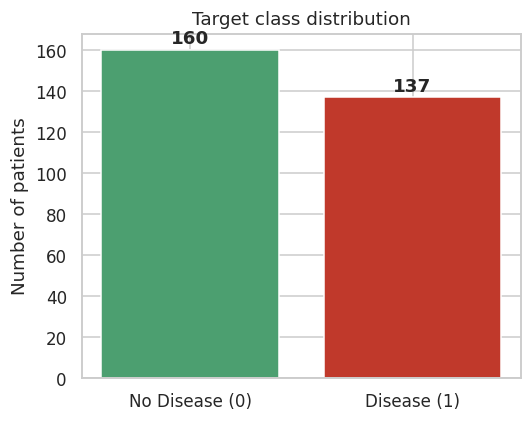

condition
0    0.538721
1    0.461279
Name: count, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["condition"].value_counts().sort_index()
ax.bar(["No Disease (0)", "Disease (1)"], counts.values, color=["#4C9F70", "#C0392B"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, str(v), ha="center", fontweight="bold")
ax.set_ylabel("Number of patients")
ax.set_title("Target class distribution")
plt.tight_layout()
plt.savefig("../reports/figures/01_target_distribution.png")
plt.show()
print(counts / len(df))

The classes are reasonably balanced (54% vs 46%), so accuracy is a meaningful metric,
though we will still track precision/recall/F1/ROC-AUC since this is a health screening
context where false negatives (missed disease) are costly.

### 2.2 Numeric feature distributions by target

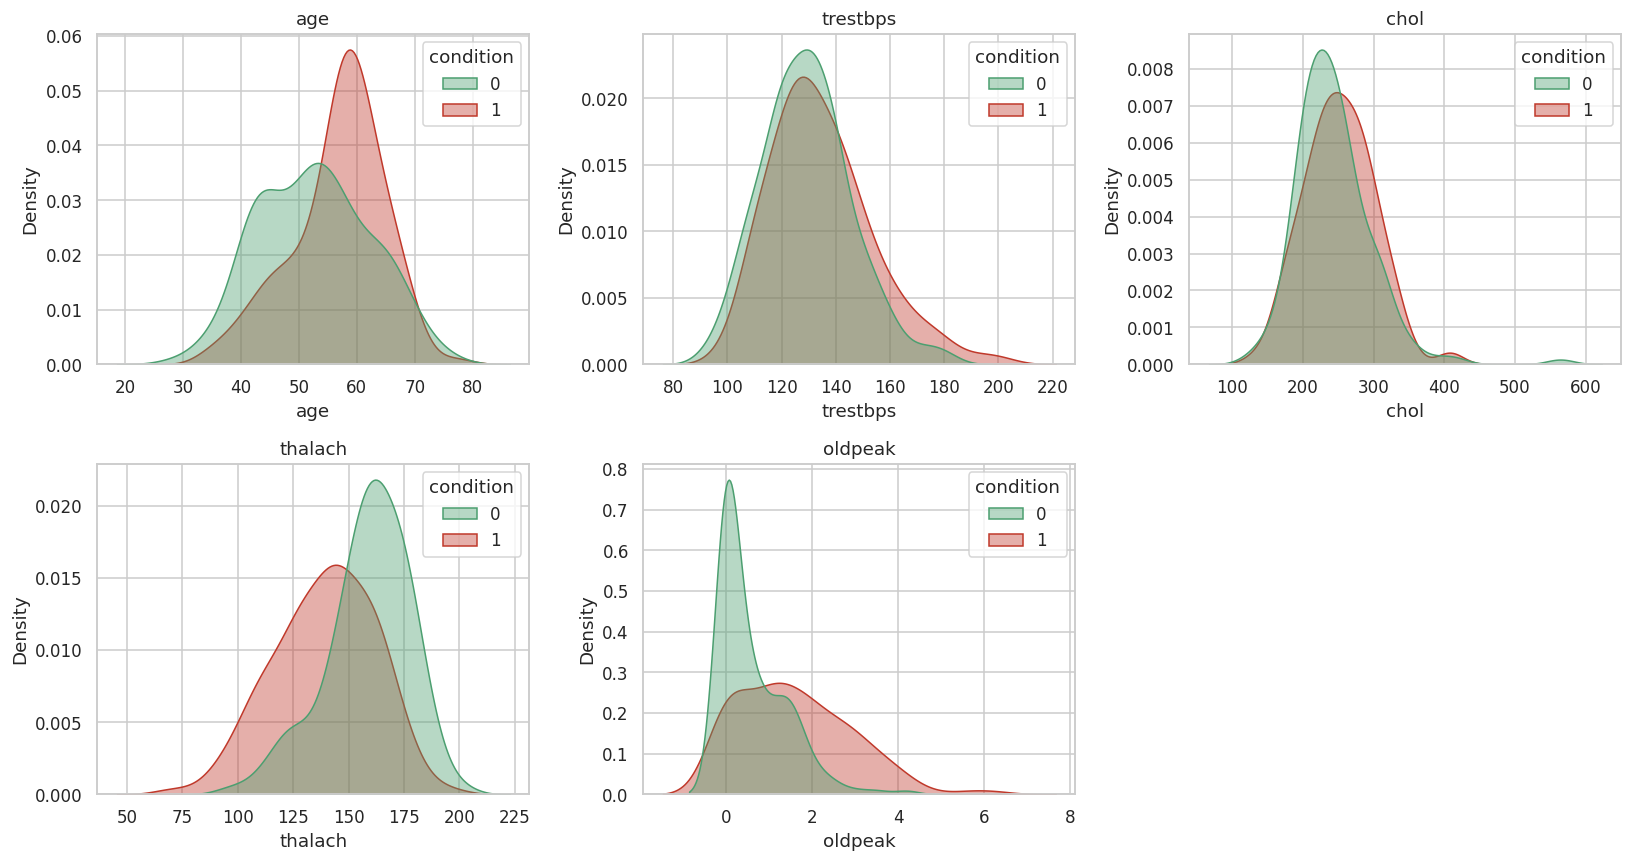

In [7]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.kdeplot(data=df, x=col, hue="condition", fill=True, alpha=0.4, ax=axes[i],
                palette={0: "#4C9F70", 1: "#C0392B"}, common_norm=False)
    axes[i].set_title(col)
axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../reports/figures/02_numeric_distributions.png")
plt.show()

### 2.3 Correlation heatmap

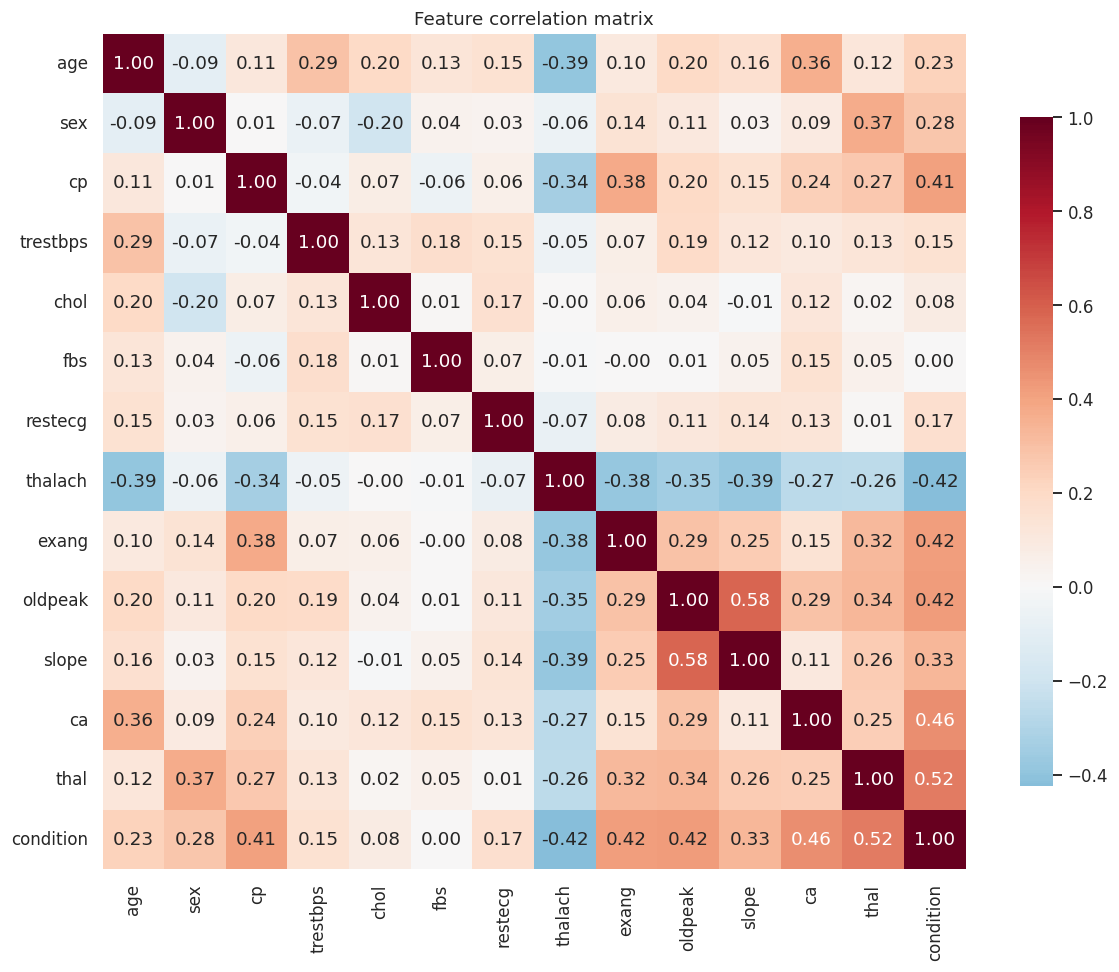

In [8]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.savefig("../reports/figures/03_correlation_heatmap.png")
plt.show()

In [9]:
corr["condition"].drop("condition").sort_values(key=abs, ascending=False)

thal        0.520516
ca          0.463189
oldpeak     0.424052
thalach    -0.423817
exang       0.421355
cp          0.408945
slope       0.333049
sex         0.278467
age         0.227075
restecg     0.166343
trestbps    0.153490
chol        0.080285
fbs         0.003167
Name: condition, dtype: float64

`thal`, `ca`, `cp`, `oldpeak`, `exang`, `thalach` and `slope` show the strongest
(linear) association with the target — consistent with clinical knowledge about
heart disease risk factors.

### 2.4 Categorical feature breakdown vs target

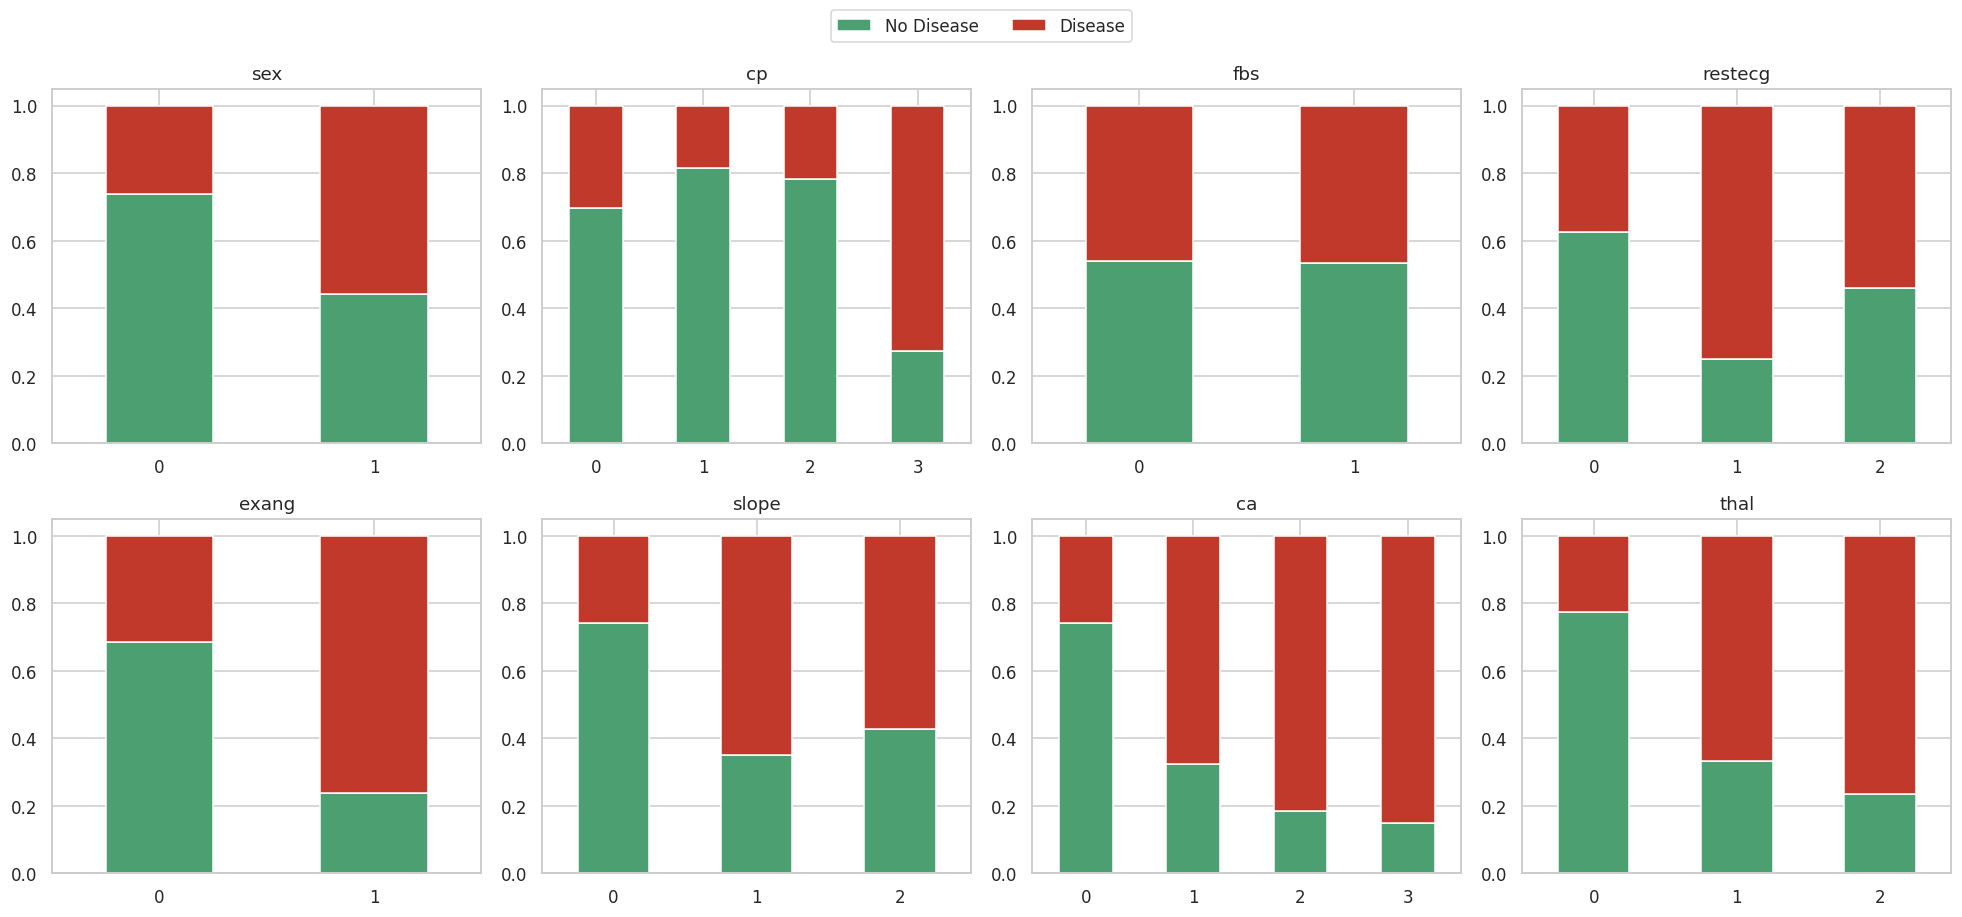

In [10]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df["condition"], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=axes[i], color=["#4C9F70", "#C0392B"], legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=0)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ["No Disease", "Disease"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout()
plt.savefig("../reports/figures/04_categorical_breakdown.png")
plt.show()

### 2.5 Outlier check

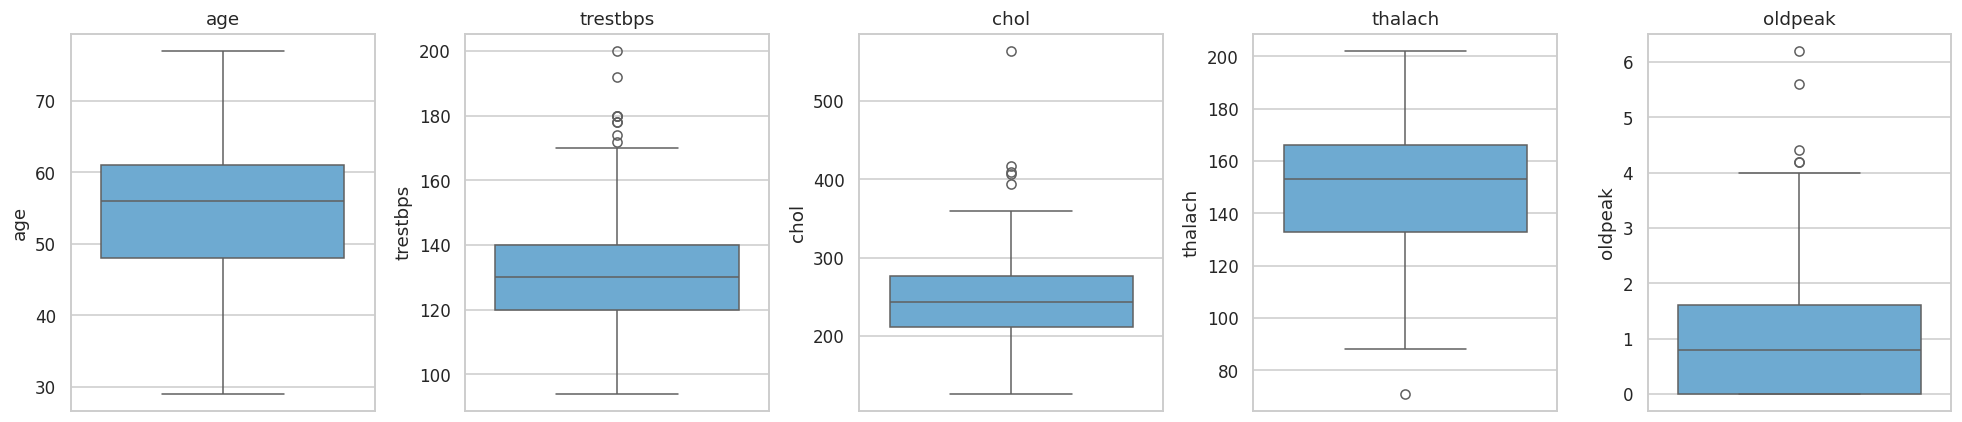

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#5DADE2")
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig("../reports/figures/05_outlier_boxplots.png")
plt.show()

A handful of high-cholesterol and high-oldpeak outliers exist but are physiologically
plausible (not data-entry errors), so we keep them — tree-based models are robust to
them, and we'll use scaling for distance-based models.

## 3. Feature engineering & preprocessing

We add a few clinically-motivated engineered features on top of the raw 13:
- `age_group`: binned age decade
- `chol_per_age`: cholesterol normalized by age
- `hr_reserve`: max heart rate relative to the age-predicted max (220 - age)
- `risk_factor_count`: count of binary risk indicators present (sex=male, fbs, exang, high chol)

In [12]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data["age_group"] = pd.cut(data["age"], bins=[0, 40, 50, 60, 70, 120],
                                labels=[0, 1, 2, 3, 4]).astype(int)
    data["chol_per_age"] = data["chol"] / data["age"]
    data["hr_reserve"] = (220 - data["age"]) - data["thalach"]
    data["risk_factor_count"] = (
        (data["sex"] == 1).astype(int) +
        (data["fbs"] == 1).astype(int) +
        (data["exang"] == 1).astype(int) +
        (data["chol"] > 240).astype(int)
    )
    return data

df_fe = engineer_features(df)
engineered_cols = ["age_group", "chol_per_age", "hr_reserve", "risk_factor_count"]
df_fe[engineered_cols].head()

,age_group,chol_per_age,hr_reserve,risk_factor_count
0,3,3.391304,20,2
1,3,3.463768,0,0
2,3,3.424242,40,0
3,3,4.338462,-19,3
4,3,3.296875,12,2


In [13]:
X = df_fe.drop(columns=["condition"])
y = df_fe["condition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

# All-numeric after engineering -> a single scaler covers everything;
# tree models ignore scaling but it doesn't hurt them.
preprocessor = ColumnTransformer(
    transformers=[("scale", StandardScaler(), list(X.columns))],
    remainder="passthrough"
)

Train shape: (237, 17)  Test shape: (60, 17)


## 4. Baseline model comparison (5-fold stratified cross-validation)

We compare 7 algorithms out of the box using identical CV folds and scoring metrics
before tuning anything, to pick promising candidates.

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    "Naive Bayes": GaussianNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

results = []
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Naive Bayes,0.797872,0.782339,0.780952,0.780294,0.879532
1,Logistic Regression,0.797961,0.793575,0.763203,0.775238,0.875481
2,Random Forest,0.768262,0.755346,0.735498,0.741529,0.870280
3,Support Vector Machine,0.777039,0.774893,0.745022,0.753756,0.865792
4,XGBoost,0.768262,0.762532,0.725541,0.740992,0.851171
5,K-Nearest Neighbors,0.772429,0.793623,0.698268,0.737308,0.847764
6,Gradient Boosting,0.768262,0.759023,0.725974,0.740147,0.841106
7,Decision Tree,0.721897,0.737525,0.633766,0.673134,0.715960


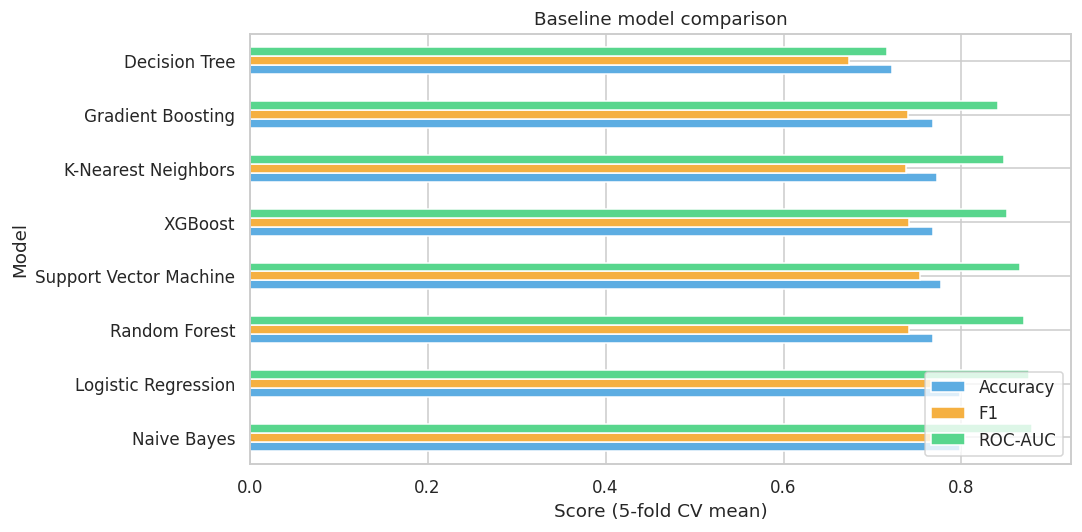

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = results_df.set_index("Model")[["Accuracy", "F1", "ROC-AUC"]]
plot_df.plot(kind="barh", ax=ax, color=["#5DADE2", "#F5B041", "#58D68D"])
ax.set_xlabel("Score (5-fold CV mean)")
ax.set_title("Baseline model comparison")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../reports/figures/06_baseline_comparison.png")
plt.show()

## 5. Hyperparameter tuning of the top 3 models

We tune the top three baseline performers with `GridSearchCV`, optimizing for
ROC-AUC (a threshold-independent metric appropriate for a screening tool).

In [16]:
param_grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {"clf__C": [0.01, 0.1, 0.5, 1, 5, 10], "clf__penalty": ["l2"], "clf__solver": ["lbfgs"]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {
            "clf__n_estimators": [200, 300, 500],
            "clf__max_depth": [3, 5, 7, None],
            "clf__min_samples_split": [2, 5, 10],
            "clf__min_samples_leaf": [1, 2, 4],
        }
    ),
    "XGBoost": (
        XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
        {
            "clf__n_estimators": [100, 200, 300],
            "clf__max_depth": [2, 3, 4, 5],
            "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "clf__subsample": [0.8, 1.0],
        }
    ),
}

top3 = results_df["Model"].head(3).tolist()
print("Tuning:", top3)

tuned_models = {}
tuning_summary = []
for name in top3:
    base_clf, grid = param_grids.get(name, (models[name], {}))
    pipe = Pipeline([("prep", preprocessor), ("clf", base_clf)])
    search = GridSearchCV(pipe, grid, cv=cv, scoring="roc_auc", n_jobs=-1)
    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    tuning_summary.append({"Model": name, "Best CV ROC-AUC": search.best_score_, "Best Params": search.best_params_})
    print(f"{name}: best CV ROC-AUC = {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")

tuning_df = pd.DataFrame(tuning_summary)
tuning_df

Tuning: ['Naive Bayes', 'Logistic Regression', 'Random Forest']
Naive Bayes: best CV ROC-AUC = 0.8795
  Best params: {}


Logistic Regression: best CV ROC-AUC = 0.8884
  Best params: {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


Random Forest: best CV ROC-AUC = 0.8868
  Best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10, 'clf__n_estimators': 500}


,Model,Best CV ROC-AUC,Best Params
0,Naive Bayes,0.879532,{}
1,Logistic Regression,0.888386,"{'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__s..."
2,Random Forest,0.886777,"{'clf__max_depth': 3, 'clf__min_samples_leaf':..."


## 6. Final evaluation on the held-out test set

In [17]:
test_results = []
for name, pipe in tuned_models.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

test_results_df = pd.DataFrame(test_results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
test_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.866667,1.000000,0.714286,0.833333,0.919643
1,Random Forest,0.833333,0.909091,0.714286,0.800000,0.917411
2,Naive Bayes,0.833333,0.950000,0.678571,0.791667,0.890625


In [18]:
best_model_name = test_results_df.iloc[0]["Model"]
best_model = tuned_models[best_model_name]
print("Selected final model:", best_model_name)

Selected final model: Logistic Regression


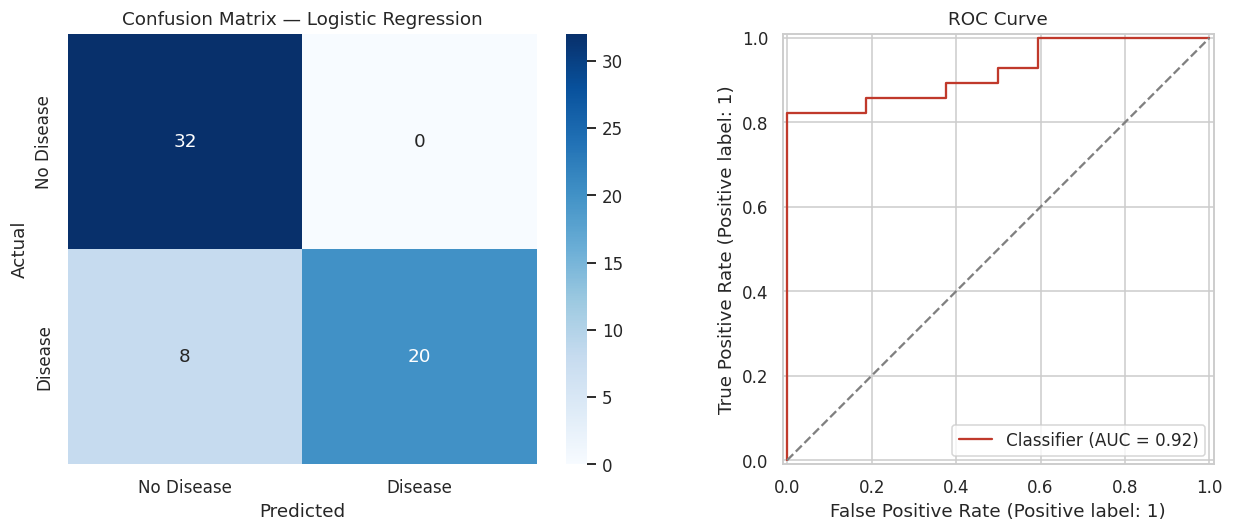

              precision    recall  f1-score   support

  No Disease       0.80      1.00      0.89        32
     Disease       1.00      0.71      0.83        28

    accuracy                           0.87        60
   macro avg       0.90      0.86      0.86        60
weighted avg       0.89      0.87      0.86        60



In [19]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"Confusion Matrix — {best_model_name}")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color="#C0392B")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.savefig("../reports/figures/07_final_model_evaluation.png")
plt.show()

print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))

## 7. Model interpretability

### 7.1 Feature importance

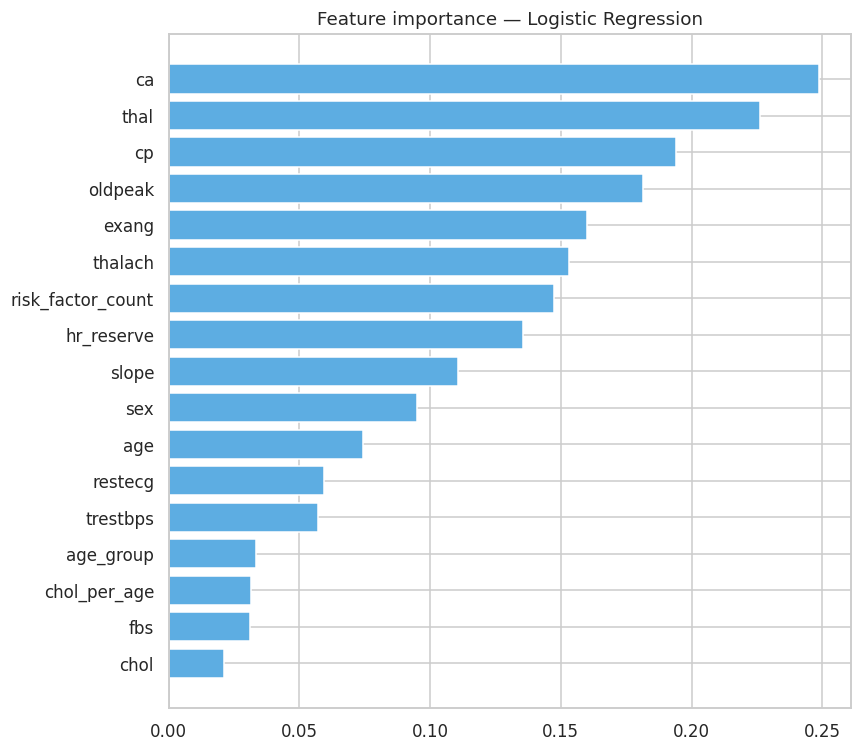

In [20]:
clf_step = best_model.named_steps["clf"]
feature_names = list(X.columns)

if hasattr(clf_step, "feature_importances_"):
    importances = clf_step.feature_importances_
elif hasattr(clf_step, "coef_"):
    importances = np.abs(clf_step.coef_[0])
else:
    importances = None

if importances is not None:
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}) \
        .sort_values("importance", ascending=True)
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(imp_df["feature"], imp_df["importance"], color="#5DADE2")
    ax.set_title(f"Feature importance — {best_model_name}")
    plt.tight_layout()
    plt.savefig("../reports/figures/08_feature_importance.png")
    plt.show()

### 7.2 SHAP values (local + global explainability)

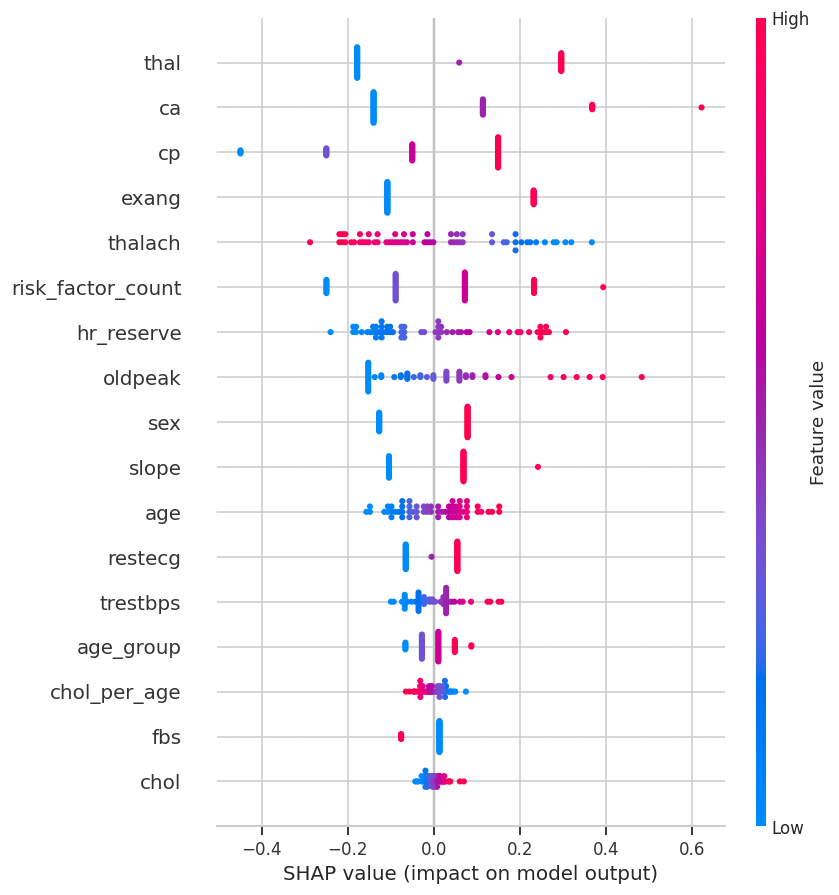

In [21]:
X_test_transformed = best_model.named_steps["prep"].transform(X_test)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

try:
    explainer = shap.Explainer(clf_step, X_test_transformed_df)
    shap_values = explainer(X_test_transformed_df)

    fig = plt.figure(figsize=(9, 7))
    shap.summary_plot(shap_values, X_test_transformed_df, show=False)
    plt.tight_layout()
    plt.savefig("../reports/figures/09_shap_summary.png", bbox_inches="tight")
    plt.show()
except Exception as e:
    print("SHAP explainer fallback (model type not directly supported):", e)

## 8. Exporting the final pipeline

We export the **entire fitted pipeline** (preprocessing + feature engineering
function + model) so the Streamlit app only has to supply the 13 raw clinical
inputs — identical to what a doctor would enter.

In [22]:
import sys
sys.path.append("../src")
from feature_engineering import FeatureEngineer  # noqa: E402

full_pipeline = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("prep", preprocessor),
    ("clf", clf_step),
])
full_pipeline.fit(X_train.drop(columns=engineered_cols, errors="ignore")
                  if False else df.loc[X_train.index].drop(columns=["condition"]),
                  y_train)

# Sanity check: predictions should match the tuned pipeline evaluated above
raw_X_test = df.loc[X_test.index].drop(columns=["condition"])
check_pred = full_pipeline.predict(raw_X_test)
print("Match with tuned pipeline predictions:", (check_pred == y_pred).mean())

joblib.dump(full_pipeline, "../models/heart_disease_pipeline.pkl")
joblib.dump({"model_name": best_model_name, "metrics": test_results_df.iloc[0].to_dict()},
            "../models/model_metadata.pkl")
print("Saved: models/heart_disease_pipeline.pkl")

Match with tuned pipeline predictions: 1.0
Saved: models/heart_disease_pipeline.pkl


## Summary

| Step | Outcome |
|---|---|
| Baseline comparison | 8 algorithms compared with 5-fold CV |
| Tuning | Top 3 tuned via GridSearchCV on ROC-AUC |
| Final model | See `best_model_name` above, evaluated on a held-out 20% test set |
| Interpretability | Feature importance + SHAP summary generated |
| Export | Full raw-input-to-prediction pipeline saved for deployment |

This notebook, the trained pipeline, and the figures in `reports/figures/` feed
directly into the Streamlit app (`app/streamlit_app.py`) and the project report.